In [1]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_initial_circuit2, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit
from quantum_functions import add_crx_gates_and_measurements_to_circuit, get_probability_distribution, calculate_kl_divergence
from quantum_functions import score_circuit_kl_divergences, plot_measurement_histograms, create_cnot_pairs_from_locations, optimize_crx_angles
from quantum_functions import vector_normalize_dictionary_values, find_best_cnot_sequence_brute_force, find_best_cnot_sequence_multi_epoch
from quantum_functions import find_best_cnot_sequence_iterative_n_wise

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc 

np.random.seed(42) 

adata = sc.read_h5ad("sim_merged_datasets_co_mo.h5ad")
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 8000 × 60
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [3]:
gl_source = ['g0', 'g1', 'g2', 'g3']
#gl_source = ['g0', 'g1', 'g3']

gl_recv = ['g5', 'g6', 'g7']

In [4]:
from scipy.sparse import issparse

ict1 = (adata.obs["CellType"] == 'CellType1') & (adata.obs['Batch2'] == 'Co')
ict2 = (adata.obs["CellType"] == 'CellType2') & (adata.obs['Batch2'] == 'Co')

adata_ct1_co = adata[ict1, gl_source].copy()
adata_ct2_co = adata[ict2, gl_recv].copy()
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

if issparse(adata_ct1_co.X):
    Xct1_co = adata_ct1_co.X.toarray()
else:
    Xct1_co = adata_ct1_co.X

if issparse(adata_ct2_co.X):
    Xct2_co = adata_ct2_co.X.toarray()
else:
    Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)


AnnData object with n_obs × n_vars = 2000 × 4
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
AnnData object with n_obs × n_vars = 2000 × 3
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]


In [5]:

ict1 = (adata.obs["CellType"] == 'CellType1') & (adata.obs['Batch2'] == 'Mo')
ict2 = (adata.obs["CellType"] == 'CellType2') & (adata.obs['Batch2'] == 'Mo')

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

if issparse(adata_ct1_mo.X):
    Xct1_mo = adata_ct1_mo.X.toarray()
else:
    Xct1_mo = adata_ct1_mo.X

if issparse(adata_ct2_mo.X):
    Xct2_mo = adata_ct2_mo.X.toarray()
else:
    Xct2_mo = adata_ct2_mo.X

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

View of AnnData object with n_obs × n_vars = 2000 × 4
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
View of AnnData object with n_obs × n_vars = 2000 × 3
    obs: 'BatchID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'CellType', 'Batch2', 'condition'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'


In [6]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

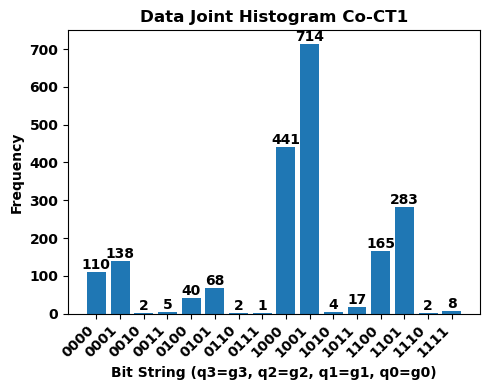

Joint Counts: Counter({'1001': 714, '1000': 441, '1101': 283, '1100': 165, '0001': 138, '0000': 110, '0101': 68, '0100': 40, '1011': 17, '1111': 8, '0011': 5, '1010': 4, '0010': 2, '1110': 2, '0110': 2, '0111': 1})
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [7]:
joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
#joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1] 
plot_joint_histogram(joint_counts_ct1_co, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_co_ct1.svg', title='Data Joint Histogram Co-CT1' )  # Pass num_qubits
#plot_joint_histogram(histogram_data, figsize=(5,4), filename = 'hist_cc_3_4pi.svg', title= r'Histogram $Ry(3\pi/4)$' )

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

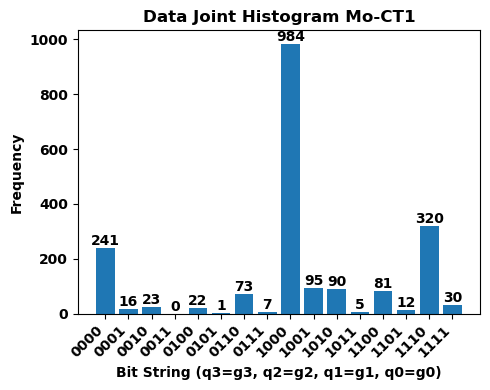

Joint Counts: Counter({'1000': 984, '1110': 320, '0000': 241, '1001': 95, '1010': 90, '1100': 81, '0110': 73, '1111': 30, '0010': 23, '0100': 22, '0001': 16, '1101': 12, '0111': 7, '1011': 5, '0101': 1})
Bit Strings: ['0000', '0001', '0010', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [8]:
joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits = num_qubits, features=gl_source, figsize = (5,4), filename = 'joint_counts_mo_ct1.svg', title='Data Joint Histogram Mo-CT1' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

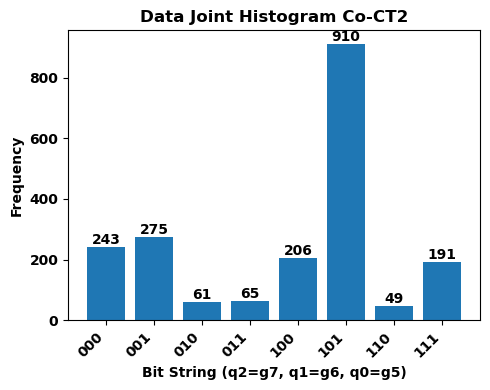

Joint Counts: Counter({'101': 910, '001': 275, '000': 243, '100': 206, '111': 191, '011': 65, '010': 61, '110': 49})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [9]:
joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
#joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_co_ct2.svg', title='Data Joint Histogram Co-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

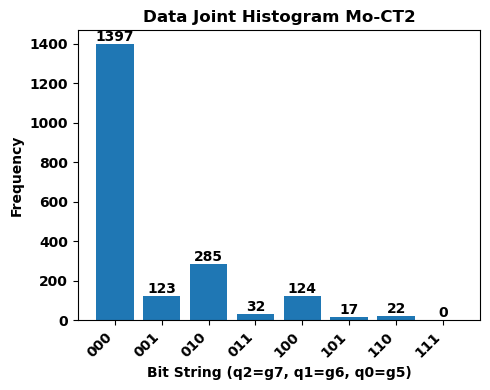

Joint Counts: Counter({'000': 1397, '010': 285, '100': 124, '001': 123, '011': 32, '110': 22, '101': 17})
Bit Strings: ['000', '001', '010', '011', '100', '101', '110']


In [10]:
joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits = num_qubits2, features=gl_recv, figsize = (5,4), filename = 'joint_counts_mo_ct2.svg', title='Data Joint Histogram Mo-CT2' )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [11]:
import numpy as np
# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set CT1 MO:", joint_counts_ct1_mo)
print("State Set CT2 MO:", joint_counts_ct2_mo)
print("Interacted State Set CT1 CO:", joint_counts_ct1_co)
print("Interacted State Set CT2 CO:", joint_counts_ct2_co)

# Apply vector normalization to the new dictionaries
normalized_joint_counts_ct1_mo = vector_normalize_dictionary_values(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = vector_normalize_dictionary_values(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = vector_normalize_dictionary_values(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = vector_normalize_dictionary_values(joint_counts_ct2_co)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_joint_counts_ct1_mo)
print("Normalized State Set 6a (Vector Norm):", normalized_joint_counts_ct2_mo)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_joint_counts_ct1_co)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_joint_counts_ct2_co)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_joint_counts_ct1_mo)
circ2 = create_initial_circuit2(normalized_joint_counts_ct2_mo)

--- New Dictionary Definitions ---
State Set CT1 MO: Counter({'1000': 984, '1110': 320, '0000': 241, '1001': 95, '1010': 90, '1100': 81, '0110': 73, '1111': 30, '0010': 23, '0100': 22, '0001': 16, '1101': 12, '0111': 7, '1011': 5, '0101': 1})
State Set CT2 MO: Counter({'000': 1397, '010': 285, '100': 124, '001': 123, '011': 32, '110': 22, '101': 17})
Interacted State Set CT1 CO: Counter({'1001': 714, '1000': 441, '1101': 283, '1100': 165, '0001': 138, '0000': 110, '0101': 68, '0100': 40, '1011': 17, '1111': 8, '0011': 5, '1010': 4, '0010': 2, '1110': 2, '0110': 2, '0111': 1})
Interacted State Set CT2 CO: Counter({'101': 910, '001': 275, '000': 243, '100': 206, '111': 191, '011': 65, '010': 61, '110': 49})

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'1000': 0.9135659365154415, '0000': 0.2237493807929079, '0111': 0.006498944670333425, '1101': 0.011141048006285872, '1111': 0.027852620015714678, '0001': 0.014854730675047828, '1010': 0.083557860

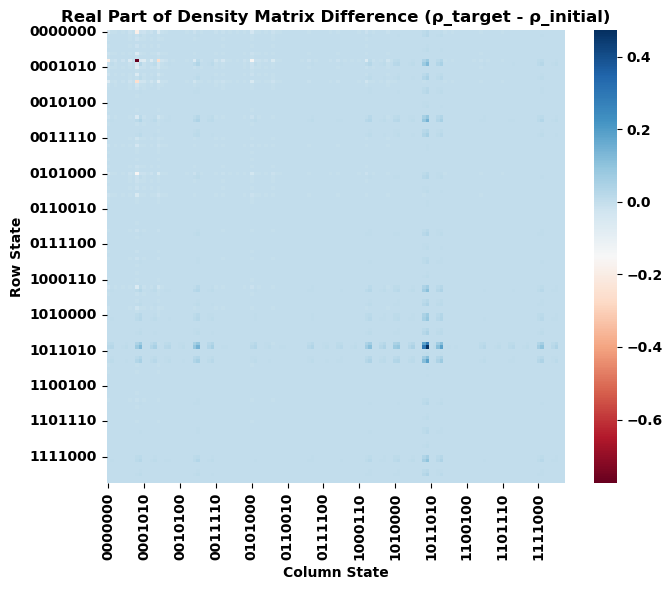


--- CNOT Candidate Analysis Summary ---
System has 7 qubits.
Total possible CNOTs (brute-force): 42
Number of refined CNOT candidates found: 6
---------------------------------------

{'max_element': 0.47244570832052063, 'min_element': -0.7758702081219088, 'abs_average': 0.0014004900968917506, 'avg_positive': 0.0014158603225045382, 'avg_negative': -0.0013575132936723066}


In [12]:
from quantum_functions import find_cnot_candidates_from_state_diff
thresh = 0.3
# --- State and Density Matrix Analysis ---
initial_cnot_config, stats = find_cnot_candidates_from_state_diff(
    normalized_joint_counts_ct1_mo, normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co, normalized_joint_counts_ct2_co,
    threshold = thresh, show_plot = True, verbose_print = True)

print(stats)


--- Running N-wise Search ---

--- Starting Iterative Pairwise Search ---


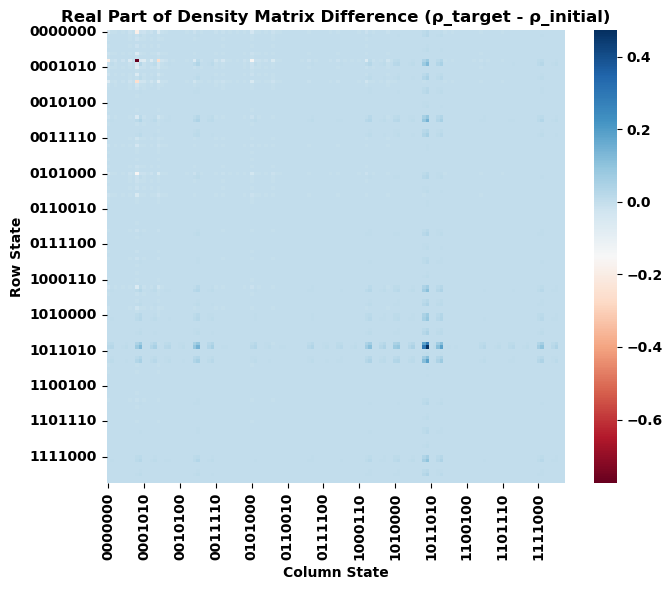


--- CNOT Candidate Analysis Summary ---
System has 7 qubits.
Total possible CNOTs (brute-force): 42
Number of refined CNOT candidates found: 6
---------------------------------------

Number of initial CNOT candidates: 6
Initial KL-divergence: 4.838427
  - Starting CNOT search -
  - No. tested pairs: 30 | Added CNOTs [(3, 6), (3, 4)] | Best pair KL sum: 2.073903
  - No. CNOT tested insertion: 6 | Added CNOT (0, 3) at index 0 | Best added KL sum: 4.765622
  - Single CNOT insertion did not improve upon the best pair.
   - Cannot perform deletion on an empty sequence.
  - Adopted new sequence. New KL Sum: 2.073903
  - No. tested pairs: 12 | Added CNOTs [(0, 3), (3, 0)] | Best pair KL sum: 1.053176
  - No. CNOT tested insertion: 12 | Added CNOT (3, 0) at index 0 | Best added KL sum: 1.041800
  - Best single CNOT insertion KL Sum: 1.041800
  - No. CNOT tested deletion: 2. Deletion did not improve KL sum.
  - Adopted new sequence. New KL Sum: 1.041800
  - No. tested pairs: 6 | No added CNOT

In [13]:
np.random.seed(42) 

print("\n" + "="*40)
print("--- Running N-wise Search ---")
print("="*40)

# Single insertion can be insertion or deletation of CX (something failing with the update criteria)
all_possible_single_cnots, best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= thresh,
    nchoose=2,
    kl_tol = 0.5, 
    ratio_kl_tol = 0.6
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'1001': 4154, '1101': 36, '1111': 469, '0000': 237, '1011': 28, '0110': 31, '0010': 2, '1000': 33, '0100': 3, '0001': 3, '1110': 4}
Counts for c_measure2: {'101': 4488, '001': 38, '100': 29, '000': 260, '010': 11, '111': 173, '110': 1}


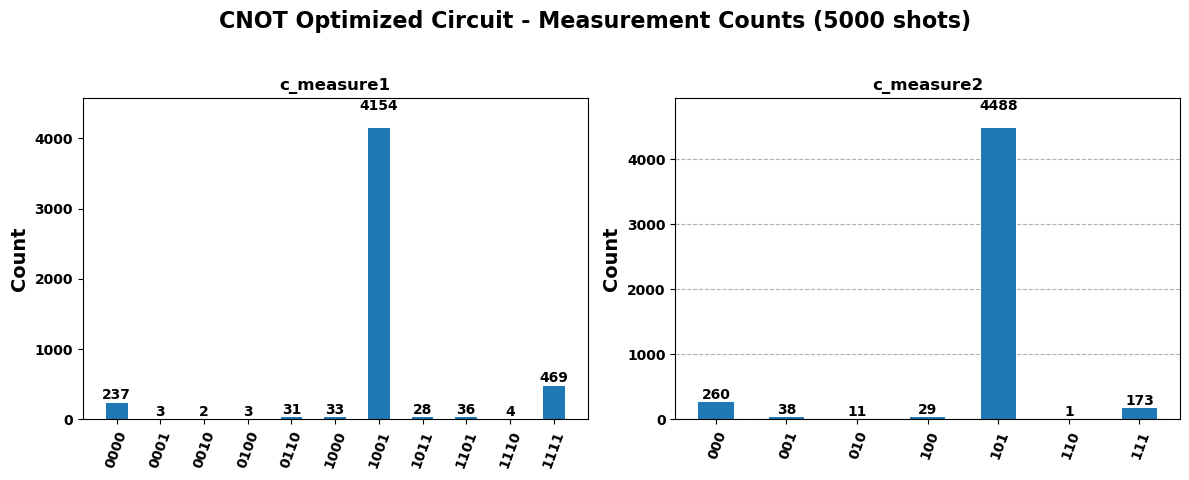

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


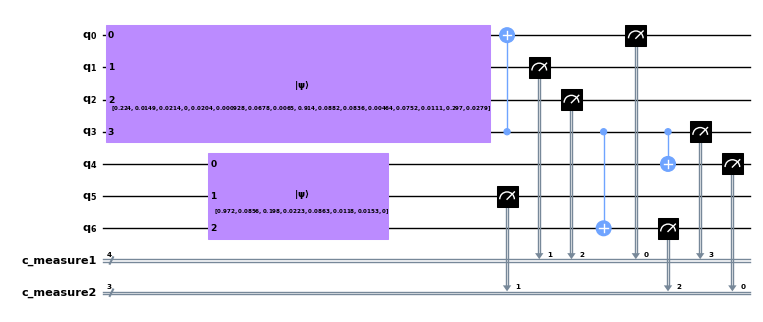

In [14]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

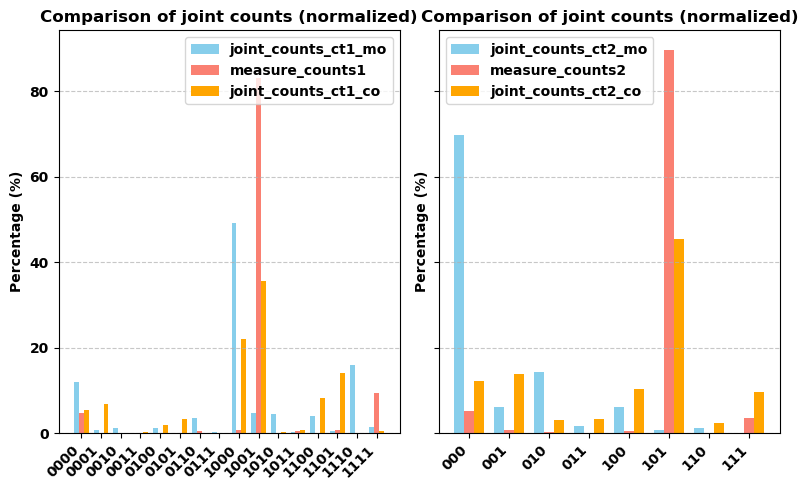

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)

# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')



--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---


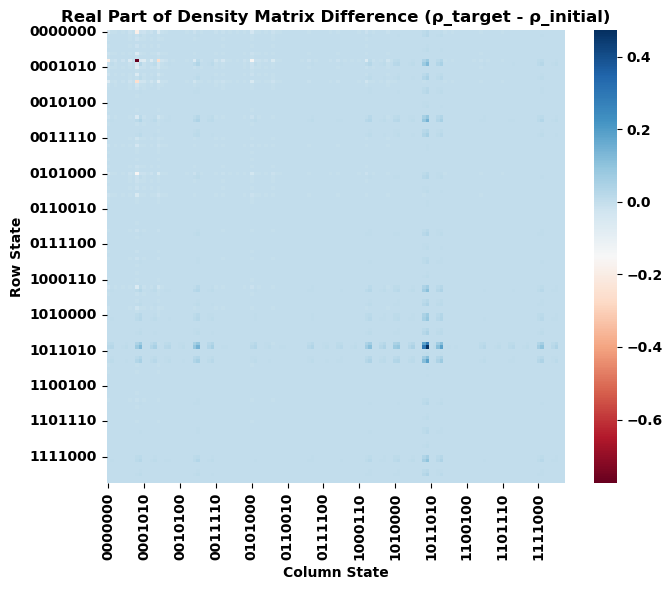


--- CNOT Candidate Analysis Summary ---
System has 7 qubits.
Total possible CNOTs (brute-force): 42
Number of refined CNOT candidates found: 6
---------------------------------------

Initial KL divergence: 4.920481

--- Starting Epoch 1/6 (Addition) with CNOT: (4, 3) (KL: 4.769361) ---
    --> Found a better KL on this path: 3.713047 at depth 2 with added CNOT (3, 0)
    --> Found a better KL on this path: 3.263479 at depth 3 with added CNOT (3, 4)
    --> Found a better KL on this path: 1.017332 at depth 4 with added CNOT (3, 6)
  Epoch 1 best KL Sum: 1.017332
  --> Epoch 1 found a new overall best KL Sum: 1.017332

--- Starting Epoch 2/6 (Addition) with CNOT: (3, 0) (KL: 3.701315) ---
    --> Found a better KL on this path: 3.305039 at depth 2 with added CNOT (3, 4)
    --> Found a better KL on this path: 1.060996 at depth 3 with added CNOT (3, 6)
  Epoch 2 best KL Sum: 1.060996

--- Starting Epoch 3/6 (Addition) with CNOT: (6, 3) (KL: 4.743787) ---
    --> Found a better KL on thi

In [16]:
np.random.seed(42) 

print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 40
min_greedy_depth = 2

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold = thresh,
    kl_tol = 0.1,
    ratio_kl_tol = 0.6
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running circuit for: CNOT Optimized Circuit ---
Counts for c_measure1: {'0000': 280, '1011': 33, '1001': 4163, '1111': 416, '1101': 32, '1000': 37, '1110': 5, '0110': 29, '0010': 3, '0100': 2}
Counts for c_measure2: {'000': 272, '101': 4462, '111': 178, '001': 71, '010': 6, '100': 5, '011': 6}


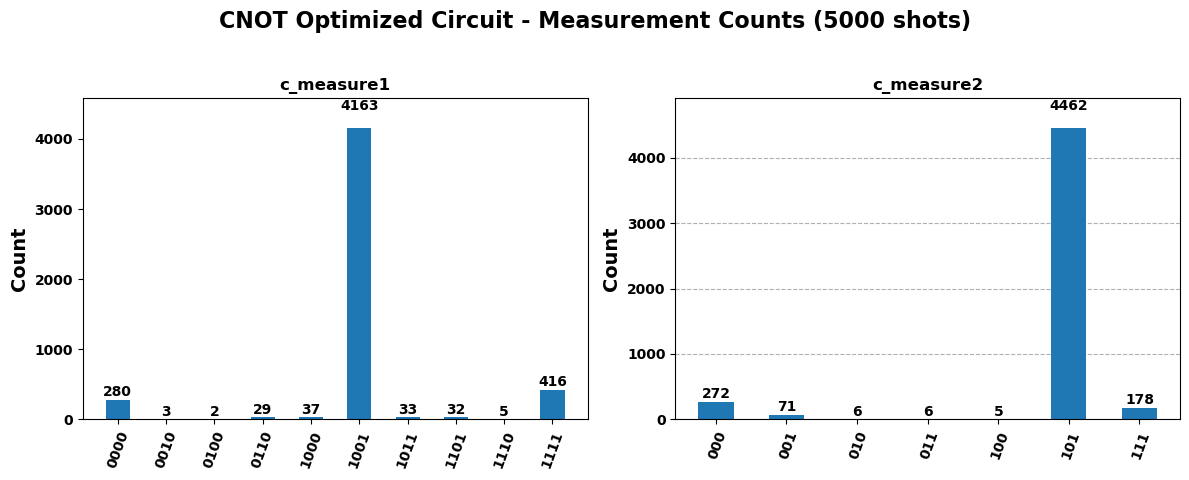

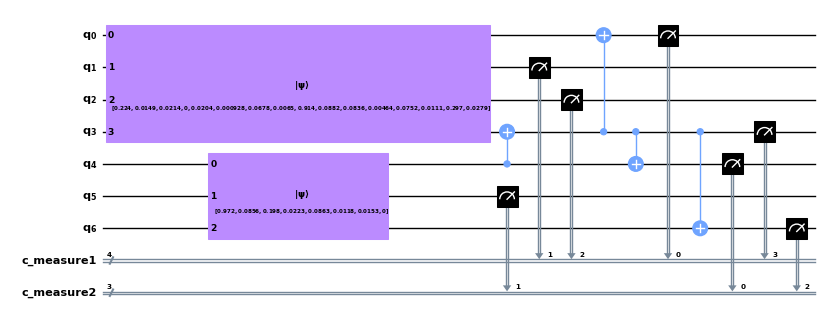

In [17]:
measure_counts1, measure_counts2 = plot_measurement_histograms( final_best_circuit_search, nshots=5000, title_prefix="CNOT Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40, scale=0.5)

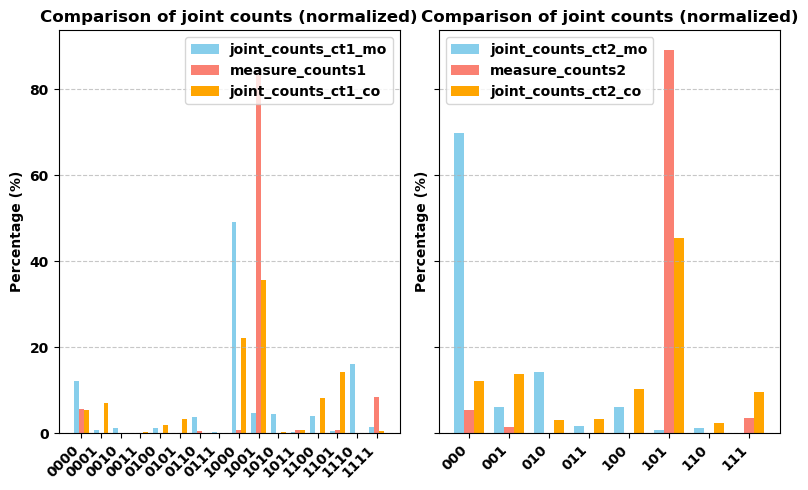

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts.svg')



--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (4 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['2.7804', '2.1121', '2.7869', '2.6779']
CRX Angle Optimization took: 10.39 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['2.7804', '2.1121', '2.7869', '2.6779']
  Minimum Combined KL Divergence with Optimized CRX: 0.763344


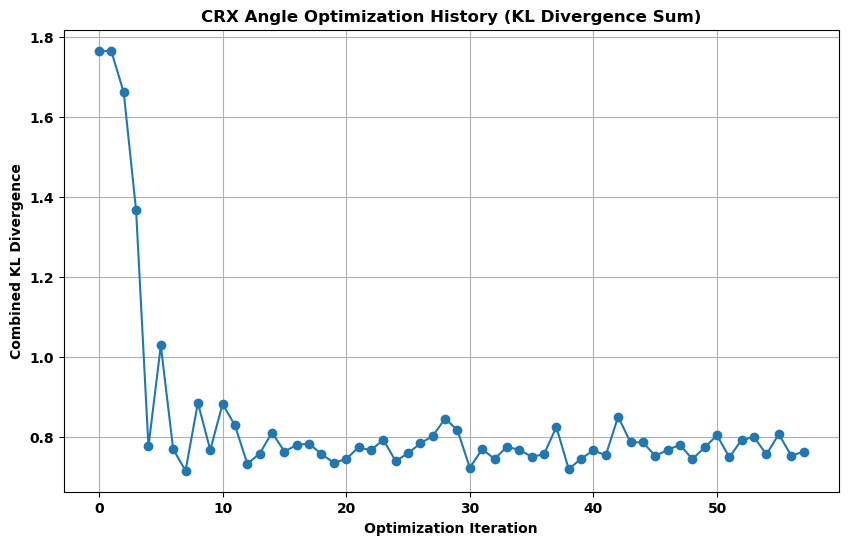


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 4/»
              »
c_measure2: 3/»
              »
«              ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«         q_0: ┤0                                                                                                                                                     ├»
«              │                                                                                                                                                      │»
«         q_1: ┤1                                                                                                                              

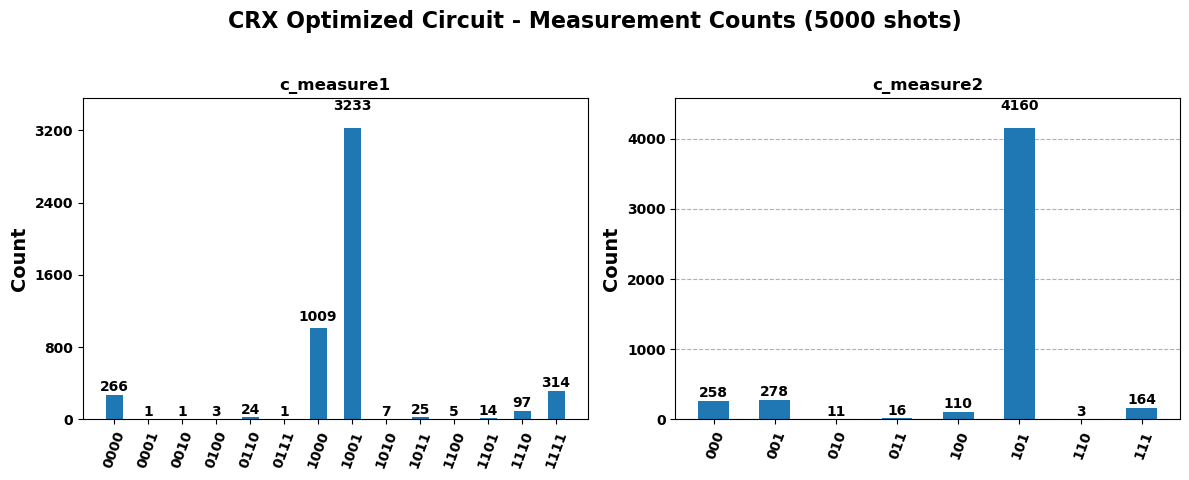

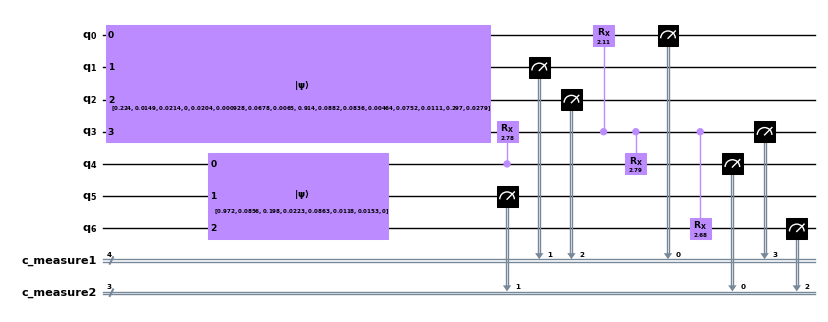

In [19]:
# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)

optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    best_cnot_sequence, # Use the CNOT topology found by brute-force
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi*1/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
measure_counts1, measure_counts2 = plot_measurement_histograms(final_crx_optimized_circuit, nshots=5000, title_prefix="CRX Optimized Circuit")
final_crx_optimized_circuit
final_crx_optimized_circuit.draw(output="mpl", style="clifford", fold=40, scale=0.5)

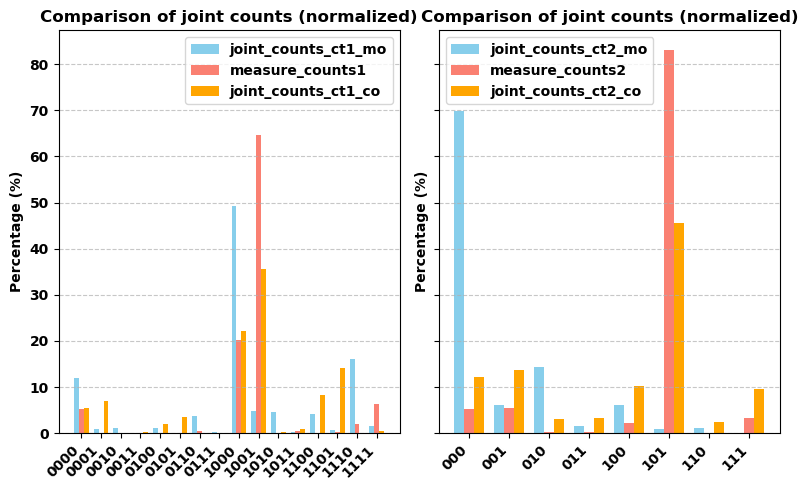

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Function to normalize dictionary values to percentages
def normalize_counts(data_dict):
    total_count = sum(data_dict.values())
    if total_count == 0:
        return {key: 0 for key in data_dict}
    return {key: (value / total_count) * 100 for key, value in data_dict.items()}

# Normalize all the data dictionaries
normalized_measure_counts1 = normalize_counts(measure_counts1)
normalized_measure_counts2 = normalize_counts(measure_counts2)
normalized_joint_counts_ct1_mo = normalize_counts(joint_counts_ct1_mo)
normalized_joint_counts_ct2_mo = normalize_counts(joint_counts_ct2_mo)
normalized_joint_counts_ct1_co = normalize_counts(joint_counts_ct1_co)
normalized_joint_counts_ct2_co = normalize_counts(joint_counts_ct2_co)


# Combine normalized data for each subplot
plot_data_columns = [
    [normalized_joint_counts_ct1_mo, normalized_measure_counts1, normalized_joint_counts_ct1_co],
    [normalized_joint_counts_ct2_mo, normalized_measure_counts2, normalized_joint_counts_ct2_co]
]
titles_columns = [
    ['joint_counts_ct1_mo', 'measure_counts1', 'joint_counts_ct1_co'],
    ['joint_counts_ct2_mo', 'measure_counts2', 'joint_counts_ct2_co']
]

# Create a figure with a 1x2 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 5), sharey=True)

# Loop through the two columns to create the plots
for i in range(2):
    current_data = plot_data_columns[i]
    current_titles = titles_columns[i]
    
    # Get all unique keys for proper alignment
    all_keys = sorted(list(set(current_data[0].keys()) | set(current_data[1].keys()) | set(current_data[2].keys())))
    x = np.arange(len(all_keys))
    width = 0.25  # Bar width
    
    # Plot bars for the three datasets
    values1 = [current_data[0].get(key, 0) for key in all_keys]
    values2 = [current_data[1].get(key, 0) for key in all_keys]
    values3 = [current_data[2].get(key, 0) for key in all_keys]

    axes[i].bar(x - width, values1, width, label=current_titles[0], color='skyblue')
    axes[i].bar(x, values2, width, label=current_titles[1], color='salmon')
    axes[i].bar(x + width, values3, width, label=current_titles[2], color='orange')
    
    # Set labels, title, and legend
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(all_keys, rotation=45, ha='right')
    axes[i].set_title(f'Comparison of joint counts (normalized)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('normalized_counts_anglkes.svg')



--- Creating QUBO matrix ---

--- Identifying Potential CNOT Linkers from Density Matrix Difference ---


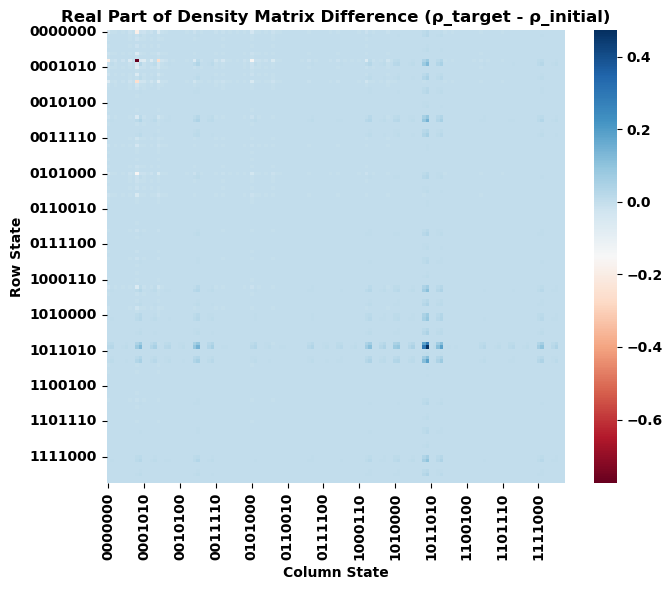


--- CNOT Candidate Analysis Summary ---
System has 7 qubits.
Total possible CNOTs (brute-force): 42
Number of refined CNOT candidates found: 6
---------------------------------------

Initial KL Divergence (no CNOTs): 4.738551

--- Building KL Divergence Matrix (6x6) ---
Calculating KL for single CNOTs (diagonal elements)...
Calculating KL for CNOT pairs (off-diagonal elements)...
Total CNOT pairs tested: 30
--- KL Divergence Matrix Built ---


In [21]:
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix
from quantum_functions import _process_target_state_input

def build_kl_divergence_matrix_for_qubo(
    circ1: QuantumCircuit,
    circ2: QuantumCircuit,
    state_probs_initial1: dict,
    state_probs_initial2: dict,
    state_vec_probs_target1: dict,
    state_vec_probs_target2: dict,
    nshots: int = 1000,
    threshold: float = 0.05,
    include_single_cnot_kl: bool = True
):
    """
    Builds a matrix where M[i][j] represents the KL divergence of the circuit
    formed by cnot_i followed by cnot_j.
    
    This function first identifies potential CNOT candidates by analyzing
    the density matrix difference between the initial and target states,
    and then calculates the KL divergence for single CNOTs and all CNOT pairs.

    Args:
        circ1 (QuantumCircuit): The first base quantum circuit.
        circ2 (QuantumCircuit): The second base quantum circuit.
        state_probs_initial1 (dict): Initial state probabilities for circ1.
        state_probs_initial2 (dict): Initial state probabilities for circ2.
        state_vec_probs_target1 (dict): Target state probabilities for circ1's part.
        state_vec_probs_target2 (dict): Target state probabilities for circ2's part.
        nshots (int): Number of shots for circuit simulation.
        threshold (float): Threshold to identify significant off-diagonal elements.
        include_single_cnot_kl (bool): If True, the diagonal M[i][i] will store
                                       the KL divergence of the circuit with only cnot_i.

    Returns:
        np.ndarray: A square matrix where M[i][j] is the KL divergence for
                    the sequence [cnot_i, cnot_j].
        dict: A mapping from CNOT tuple to its index in the matrix.
        list: The list of initial CNOT candidates used.
        float: The initial KL divergence for the circuit with no CNOTs.
    """
    ng_circ1 = circ1.num_qubits
    ng_circ2 = circ2.num_qubits
    
    print(f"\n--- Identifying Potential CNOT Linkers from Density Matrix Difference ---")


    # --- State and Density Matrix Analysis ---
    initial_cnot_config, stats = find_cnot_candidates_from_state_diff(
        state_probs_initial1, state_probs_initial2,
        state_vec_probs_target1, state_vec_probs_target2, 
        threshold= threshold, verbose_print = True,
        plot_filename = None, show_plot = True
        )

    # --- Calculate Baseline KL Divergence (no CNOTs) ---
    base_combined_circuit = concatenate_circuits_with_separate_measurements(circ1, circ2)
    base_circuit_no_cnots = add_cnots_and_measurements_to_circuit(base_combined_circuit, ng_circ1, [])
    kl_divs_baseline = score_circuit_kl_divergences(base_circuit_no_cnots, state_vec_probs_target1, state_vec_probs_target2, nshots)
    initial_kl_sum = kl_divs_baseline[0] + kl_divs_baseline[1] if kl_divs_baseline is not None else float('inf')
    print(f"Initial KL Divergence (no CNOTs): {initial_kl_sum:.6f}")

    # --- Start building the matrix with the identified candidates ---
    num_candidates = len(initial_cnot_config)
    kl_divergence_matrix = np.full((num_candidates, num_candidates), np.inf)
    cnot_to_index = {tuple(cnot): i for i, cnot in enumerate(initial_cnot_config)}

    print(f"\n--- Building KL Divergence Matrix ({num_candidates}x{num_candidates}) ---")

    if include_single_cnot_kl:
        print("Calculating KL for single CNOTs (diagonal elements)...")
        for i, cnot_i in enumerate(initial_cnot_config):
            trial_circuit = add_cnots_and_measurements_to_circuit(
                base_combined_circuit, ng_circ1, [cnot_i]
            )
            kl_divs = score_circuit_kl_divergences(
                trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
            )
            if kl_divs is not None:
                kl_divergence_matrix[i, i] = kl_divs[0] + kl_divs[1]
                # print(f"  KL for [{cnot_i}]: {kl_divergence_matrix[i, i]:.6f}")

    print("Calculating KL for CNOT pairs (off-diagonal elements)...")
    n_pairs_tested = 0
    for cnot_i_val in initial_cnot_config:
        for cnot_j_val in initial_cnot_config:
            idx_i = cnot_to_index[tuple(cnot_i_val)]
            idx_j = cnot_to_index[tuple(cnot_j_val)]

            if idx_i == idx_j:
                continue

            n_pairs_tested += 1
            trial_sequence = [cnot_i_val, cnot_j_val]
            trial_circuit = add_cnots_and_measurements_to_circuit(
                base_combined_circuit, ng_circ1, trial_sequence
            )
            kl_divs = score_circuit_kl_divergences(
                trial_circuit, state_vec_probs_target1, state_vec_probs_target2, nshots
            )
            if kl_divs is not None:
                kl_divergence_matrix[idx_i, idx_j] = kl_divs[0] + kl_divs[1]
                # print(f"  KL for [{cnot_i_val}, {cnot_j_val}]: {kl_divergence_matrix[idx_i, idx_j]:.6f}")
    
    print(f"Total CNOT pairs tested: {n_pairs_tested}")
    print("--- KL Divergence Matrix Built ---")

    return kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum

np.random.seed(42) 

print("\n" + "="*40)
print("--- Creating QUBO matrix ---")
print("="*40)
    
kl_divergence_matrix, cnot_to_index, initial_cnot_config, initial_kl_sum = build_kl_divergence_matrix_for_qubo(
    circ1,
    circ2,
    normalized_joint_counts_ct1_mo,
    normalized_joint_counts_ct2_mo,
    normalized_joint_counts_ct1_co,
    normalized_joint_counts_ct2_co,
    nshots=5000,
    threshold= 0.4, 
    include_single_cnot_kl=True
)

In [ ]:
import numpy as np
import numpy as np

def kl_to_qubo_matrix(kl_matrix: np.ndarray, initial_kl_sum: float) -> np.ndarray:
    """
    Builds a QUBO matrix from a KL divergence matrix.

    This function transforms a matrix of KL divergences into a Quadratic Unconstrained
    Binary Optimization (QUBO) matrix. The resulting matrix can be used by a
    QUBO solver to find the optimal selection of CNOT gates that minimizes
    the KL divergence of a quantum circuit.

    The QUBO problem is formulated to minimize a cost function where the energy
    of a solution (a set of selected CNOTs) corresponds to the circuit's
    relative KL divergence.

    Args:
        kl_matrix (np.ndarray): A square matrix where:
                                - kl_matrix[k, k] is the KL divergence of a circuit with a
                                  single CNOT gate `k`.
                                - kl_matrix[k, l] is the KL divergence of a circuit with
                                  the sequence of CNOT gates `k` then `l`.
        initial_kl_sum (float): The baseline KL divergence of the circuit with
                                no CNOT gates. This value is used to calculate
                                the cost relative to the zero-CNOT circuit.

    Returns:
        np.ndarray: The resulting QUBO matrix, Q. This is an upper triangular
                    matrix (with the diagonal included) containing the coefficients
                    for the QUBO objective function:
                    E(x) = sum(Q_ij * x_i * x_j) for i <= j.
                    
    Raises:
        ValueError: If kl_matrix is not a square matrix.
    """
    if kl_matrix.shape[0] != kl_matrix.shape[1]:
        raise ValueError("kl_matrix must be a square matrix.")

    num_vars = kl_matrix.shape[0]
    qubo_matrix = np.zeros((num_vars, num_vars))

    # A large penalty is assigned to invalid or infinite KL divergences to
    # discourage the solver from selecting those CNOT gates or pairs.
    INF_PENALTY = 1e9

    # --- Step 1: Calculate Linear Coefficients (Diagonal Terms, Q_ii) ---
    # These terms represent the cost of selecting a single CNOT gate.
    for i in range(num_vars):
        if not np.isinf(kl_matrix[i, i]):
            # The linear cost is the single-gate KL divergence relative to the baseline.
            cost_i = kl_matrix[i, i] - initial_kl_sum
            qubo_matrix[i, i] = cost_i
        else:
            # Assign a large penalty for an infinite KL divergence.
            qubo_matrix[i, i] = INF_PENALTY

    # --- Step 2: Calculate Quadratic Coefficients (Off-Diagonal Terms, Q_ij) ---
    # These terms represent the synergistic interaction cost of selecting a pair
    # of CNOT gates, isolated from their individual contributions.
    for i in range(num_vars):
        for j in range(i + 1, num_vars):
            kl_ij = kl_matrix[i, j]
            kl_ji = kl_matrix[j, i]

            if not np.isinf(kl_ij) and not np.isinf(kl_ji):
                # We must choose *one* order to encode in Q_ij.
                # The lowest KL divergence of the two orders is the target cost.
                kl_best_order = min(kl_matrix[i, j], kl_matrix[j, i])
                
                # Get the pre-computed linear costs from the diagonal of the QUBO matrix.
                cost_i = qubo_matrix[i, i]
                cost_j = qubo_matrix[j, j]
                
                # Isolate the interaction cost using the BEST of the two orders.
                # This simplifies the optimization: if the solver chooses i and j, 
                # the cost will reflect the best physical sequence.
                interaction_cost = (kl_best_order - initial_kl_sum) - cost_i - cost_j
                qubo_matrix[i, j] = interaction_cost
                
            else:
                # Assign a large penalty if the KL divergence for the pair is infinite.
                qubo_matrix[i, j] = INF_PENALTY

    return qubo_matrix

# Creating Q matrix 
kl_div_mat_qubo = kl_to_qubo_matrix(kl_matrix = kl_divergence_matrix, initial_kl_sum = initial_kl_sum)

In [88]:
from qiskit_optimization import QuadraticProgram
from qiskit.quantum_info import SparsePauliOp
import numpy as np

# Assume kl_div_mat_qubo is your 42x42 NumPy array

num_qubits = kl_div_mat_qubo.shape[0]

# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")

for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')

# Set the objective function to minimize the cost defined by the QUBO matrix
# The matrix must be passed as the 'quadratic' term.
#qp.minimize(quadratic=kl_div_mat_qubo, linear=kl_vec)
qp.minimize(quadratic=kl_div_mat_qubo)

# --- 2. Convert the QUBO to an Ising Hamiltonian ---
# The Ising Converter performs the necessary transformation (x = (1 - Z)/2)
hamiltonian, offset = qp.to_ising()
print(offset)
print(hamiltonian)

-1.3849859897100318
SparsePauliOp(['IIIIIZ', 'IIIIZZ', 'IIIIZI', 'IIIZIZ', 'IIIZII', 'IIZIIZ', 'IIZIII', 'IZIIIZ', 'IZIIII', 'ZIIIIZ', 'ZIIIII', 'IIIZZI', 'IIZIZI', 'IZIIZI', 'ZIIIZI', 'IIZZII', 'IZIZII', 'ZIIZII', 'IZZIII', 'ZIZIII', 'ZZIIII'],
              coeffs=[ 0.05075771+0.j, -0.01704273+0.j,  0.6042281 +0.j,  0.00541556+0.j,
  0.84680915+0.j, -0.01495191+0.j,  0.56006472+0.j,  0.00154897+0.j,
  0.04196834+0.j, -0.03033635+0.j,  0.12252642+0.j, -0.01987048+0.j,
 -0.00746718+0.j, -0.01294887+0.j, -0.05828219+0.j, -0.57559115+0.j,
 -0.00314933+0.j, -0.04418072+0.j, -0.00096283+0.j, -0.00988344+0.j,
 -0.05366579+0.j])


In [106]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_aer import AerSimulator
from qiskit.circuit.library import EfficientSU2
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile
import numpy as np

# --- 1. Configuration (Example values) ---
num_qubits = kl_div_mat_qubo.shape[0]
reps = 1
entanglement = 'circular'  # linear sca circular pairwise reverse_linear full

# --- 2. Ansatz Creation ---
ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)

basis_gates = ['u', 'cx'] 
# 2. Transpile the circuit to decompose it into the basis gates.
expanded_ansatz = transpile(
    ansatz, 
    basis_gates = basis_gates, 
    optimization_level = 0  # Set to 0 to minimize changes beyond decomposition
)

# To run on hardware, select the backend with the fewest number of jobs in the queue
backend = AerSimulator()
#backend = service.least_busy(operational=True, simulator=False)
expanded_ansatz.draw()

C:\Users\ssromerogon\AppData\Local\Temp\ipykernel_31760\4128365459.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2( num_qubits=num_qubits, entanglement=entanglement, reps=reps)


global phase: -θ[6]/2 - θ[7]/2 - θ[8]/2 - θ[9]/2 - θ[10]/2 - θ[11]/2 - θ[18]/2 - θ[19]/2 - θ[20]/2 - θ[21]/2 - θ[22]/2 - θ[23]/2
     ┌─────────────┐┌─────────────┐ ┌───┐     ┌──────────────┐┌──────────────┐»
q_0: ┤ U(θ[0],0,0) ├┤ U(0,0,θ[6]) ├─┤ X ├──■──┤ U(θ[12],0,0) ├┤ U(0,0,θ[18]) ├»
     ├─────────────┤├─────────────┤ └─┬─┘┌─┴─┐└──────────────┘├──────────────┤»
q_1: ┤ U(θ[1],0,0) ├┤ U(0,0,θ[7]) ├───┼──┤ X ├───────■────────┤ U(θ[13],0,0) ├»
     ├─────────────┤├─────────────┤   │  └───┘     ┌─┴─┐      └──────────────┘»
q_2: ┤ U(θ[2],0,0) ├┤ U(0,0,θ[8]) ├───┼────────────┤ X ├─────────────■────────»
     ├─────────────┤├─────────────┤   │            └───┘           ┌─┴─┐      »
q_3: ┤ U(θ[3],0,0) ├┤ U(0,0,θ[9]) ├───┼────────────────────────────┤ X ├──────»
     ├─────────────┤├─────────────┴┐  │                            └───┘      »
q_4: ┤ U(θ[4],0,0) ├┤ U(0,0,θ[10]) ├──┼───────────────────────────────────────»
     ├─────────────┤├──────────────┤  │                                       »
q_5: ┤ U(θ[5],0,0) ├┤ U(0,0,θ[11]) ├──■───────────────────────────────────────»
     └─────────────┘└──────────────┘                                          »
«                                                                     
«q_0: ────────────────────────────────────────────────────────────────
«     ┌──────────────┐                                                
«q_1: ┤ U(0,0,θ[19]) ├────────────────────────────────────────────────
«     ├──────────────┤┌──────────────┐                                
«q_2: ┤ U(θ[14],0,0) ├┤ U(0,0,θ[20]) ├────────────────────────────────
«     └──────────────┘├──────────────┤┌──────────────┐                
«q_3: ───────■────────┤ U(θ[15],0,0) ├┤ U(0,0,θ[21]) ├────────────────
«          ┌─┴─┐      └──────────────┘├──────────────┤┌──────────────┐
«q_4: ─────┤ X ├─────────────■────────┤ U(θ[16],0,0) ├┤ U(0,0,θ[22]) ├
«          └───┘           ┌─┴─┐      ├──────────────┤├──────────────┤
«q_5: ─────────────────────┤ X ├──────┤ U(θ[17],0,0) ├┤ U(0,0,θ[23]) ├
«                          └───┘      └──────────────┘└──────────────┘

In [107]:
import numpy as np
import matplotlib.pyplot as plt
#from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

def vqe_solver(
    ansatz, # Renamed from 'cirquit' for common convention
    hamiltonian,
    backend,
    optimizer_method: str = "COBYLA", # "L-BFGS-B | COBYLA
    niter: int = 100
):
    """
    Performs a Variational Quantum Eigensolver (VQE) optimization.

    This function encapsulates the VQE workflow, including:
    1. Creating an interaction observable from histogram data.
    2. Setting up static and variable parameters for the quantum circuit.
    3. Initializing the Qiskit StatevectorEstimator.
    4. Running the optimization using scipy.optimize.minimize.
    5. Collecting cost function values during optimization.
    6. Updating parameters with optimized values.
    7. (Optional) Plotting the energy minimization curve.

    Args:
        circuit (QuantumCircuit): The parameterized quantum circuit (ansatz).
        act_percentages (list): Initial percentage values for parameters
                                containing '_act_' in the circuit.
        cost_func_wrapper (callable): The cost function to be minimized.
                                      It MUST accept arguments in the following order:
                                      cost_func_wrapper(current_variable_params_array,
                                                        static_params_dict,
                                                        circuit,
                                                        observable,
                                                        estimator,
                                                        variable_param_objects_list)
                                      Inside this function, you should combine
                                      static_params_dict and map current_variable_params_array
                                      to variable_param_objects_list to form the
                                      full parameter dictionary for circuit binding.
        min_ones_for_observable (int): Minimum number of '1's for filtering
                                       histogram data when creating the observable.
        optimizer_method (str): The optimization method to use for scipy.minimize
                                (e.g., "L-BFGS-B", "COBYLA", "SLSQP").

    Returns:
        tuple: A tuple containing:
            - result_object (OptimizeResult): The result object from scipy.optimize.minimize.
            - optimized_full_params (dict): The dictionary of all parameters
                                            with their final optimized values.
            - cost_history (list): A list of cost function values recorded
                                   during each optimization iteration.
    """
    # 1. Define the base options dictionary
    options = {
        "disp": False, # Optional: Set to True to display solver messages
        "tol": 1e-4,   # Optional: Set the tolerance for termination
        "maxiter":niter
    }

    num_qubits = ansatz.num_qubits # Get number of qubits from the circuit

    # make quantum circuit compatible to the backend
    pm = generate_preset_pass_manager(backend = backend, optimization_level=3)
    ansatz_isa = pm.run(ansatz)

    estimator = Estimator(mode=backend)
    estimator.options.default_shots = 1024

    # 4. Prepare initial guess for optimization initialize 0 vector
    num_params = ansatz.num_parameters 
    #x0_interaction = np.random.rand(num_params) * 2 * np.pi
    #x0_interaction = np.zeros(num_params)
    x0_interaction = np.ones(num_params)*np.pi/2
    #x0_interaction = np.ones(num_params)*np.pi
    
    # in the context of the vqe_solver function scope.
    iteration_data = {'counter': 0} 
    cost_values = [] # List to store cost values at each iteration
    
    def cost_func_vqe(params, ansatz, hamiltonian, estimator):
        """Return estimate of energy from estimator
        Parameters:
            params (ndarray): Array of ansatz parameters
            ansatz (QuantumCircuit): Parameterized ansatz circuit
            hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
            estimator (EstimatorV2): Estimator primitive instance
            cost_history_dict: Dictionary for storing intermediate results
    
        Returns:
            float: Energy estimate
        """
        pub = (ansatz, [hamiltonian], [params])
        result = estimator.run(pubs=[pub]).result()
        energy = result[0].data.evs[0]

        return energy
 
    def cost_func_wrapper(xk, ansatz, hamiltonian, estimator):
        return  cost_func_vqe(xk, ansatz, hamiltonian, estimator) # Pass combined_qc

    # Define the callback function for minimize
    def callback_func(xk):
        # Access the counter from the enclosing scope's dictionary
        current_counter = iteration_data['counter']
        if current_counter > 100:
            print_criteria = 100
        else:
            print_criteria = 20

        current_cost = cost_func_wrapper(xk, ansatz, hamiltonian, estimator)
        cost_values.append(current_cost)

        # Print the current cost only every 20 iterations
        if current_counter % print_criteria == 0 or current_counter == 0:
            print(f"Iteration {current_counter}: Current cost: {current_cost}")
            
        iteration_data['counter'] += 1 # Increment the counter

    # 6. Call minimize with args
    print(f"Starting optimization with method: {optimizer_method}")
    result_interaction = minimize(
        cost_func_wrapper,
        x0_interaction,
        # IMPORTANT: Pass static_params and variable_param_objects as fixed arguments
        # The cost_func_wrapper will use xk (the first argument) with these to bind parameters.
        args=(ansatz_isa, hamiltonian, estimator),
        method=optimizer_method, # Use the passed optimizer_method
        callback=callback_func, # Use the defined callback function
        options=options,
    )

    print("\nOptimization Result:")
    print(result_interaction)
    print(f"\nFinal Energy: {result_interaction.fun}")

    # Update the full parameter dictionary with optimized variable parameters
    opt_values = result_interaction.x # opt_values is the numpy.ndarray
       
    opt_params_dict = dict(zip(ansatz.parameters, opt_values))
    # The keys of this dictionary are the symbolic parameter objects

    print("\nOptimized Full Parameters:")
    for param, value in opt_params_dict.items():
        # Now 'param' is the symbolic object with a '.name' attribute
        print(f"  {param.name}: {value}")

    # Return the results
    return result_interaction, opt_params_dict, cost_values

Starting optimization with method: COBYLA
Iteration 0: Current cost: -0.026617605669755382
Iteration 20: Current cost: -1.7480457949997852
Iteration 40: Current cost: -2.3422855405574996
Iteration 60: Current cost: -2.300935094718693
Iteration 80: Current cost: -2.541206090584478
Iteration 100: Current cost: -2.61391480530173
Iteration 200: Current cost: -2.6299626911456713

Optimization Result:
 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 2
     fun: -2.681752257826558
       x: [ 2.660e+00  1.485e+00 ...  1.436e+00  2.026e+00]
    nfev: 200
   maxcv: 0.0

Final Energy: -2.681752257826558

Optimized Full Parameters:
  θ[0]: 2.65983433976822
  θ[1]: 1.4853588408679659
  θ[2]: 1.6782309842016339
  θ[3]: 1.5492777109871978
  θ[4]: 1.727018057381566
  θ[5]: 1.93258861905496
  θ[6]: 2.9664815241545512
  θ[7]: 3.0796162936996945
  θ[8]: 3.3048567117491077
  θ[9]: 3.0407369380693754
  θ[10]: 2.945586662703745
  θ[11]: 2.7417405555613827
  θ[12

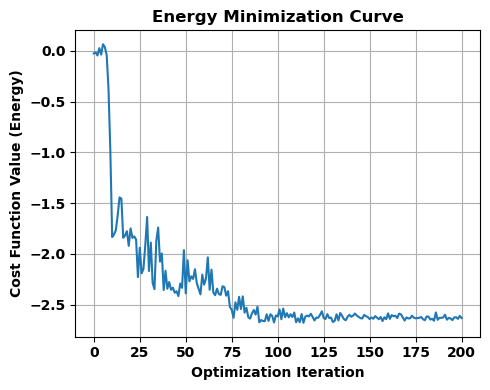

In [108]:
result, optimized_params, cost_values = vqe_solver(
    expanded_ansatz,
    hamiltonian,
    backend,
    optimizer_method="COBYLA", # COBYLA | L-BFGS-B 
    niter= 200
)

# Plot the cost function values
plt.figure(figsize=(5, 4))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
#plt.savefig('vqe_opt_curve_qmat.svg', bbox_inches='tight')
plt.show()    

In [109]:
def evaluate_and_plot_ansatz(ansatz, params, shots=1024, title="VQE Quantum Sampler Results", figsize=(5, 4), filename=None):
    """Evaluates a quantum ansatz, plots results and circuit, and prints counts."""
    try:
        backend = AerSimulator()
        sampler = Sampler(mode=backend)
        bound_circuit = ansatz.copy()
        bound_circuit.assign_parameters(params, inplace=True)
        bound_circuit.measure_all()

        pm = generate_preset_pass_manager(backend = backend, optimization_level=3)
        bound_circuit = pm.run(bound_circuit)

        job = sampler.run([bound_circuit], shots=shots)
        pub_result = job.result()[0]
        data_pub = pub_result.data
        counts = data_pub.meas.get_counts()

        # Matplotlib customization:
        sorted_counts = dict(sorted(counts.items()))
        x_labels = list(sorted_counts.keys())
        y_values = list(sorted_counts.values())

        plt.figure(figsize=figsize)
        plt.bar(x_labels, y_values)
        plt.xlabel("Measurement Outcomes")
        plt.ylabel("Counts")
        plt.title(title)
        plt.xticks(rotation=45, ha='right')
        #plt.xlabel("Measurement Outcomes", fontsize=16)
        #plt.ylabel("Counts", fontsize=16)
        #plt.title(title, fontsize=18)
        #plt.xticks(rotation=45, ha='right', fontsize=14)
        plt.tight_layout()
        if filename:
            plt.savefig(filename, bbox_inches='tight')
        plt.show()

        return counts, bound_circuit

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

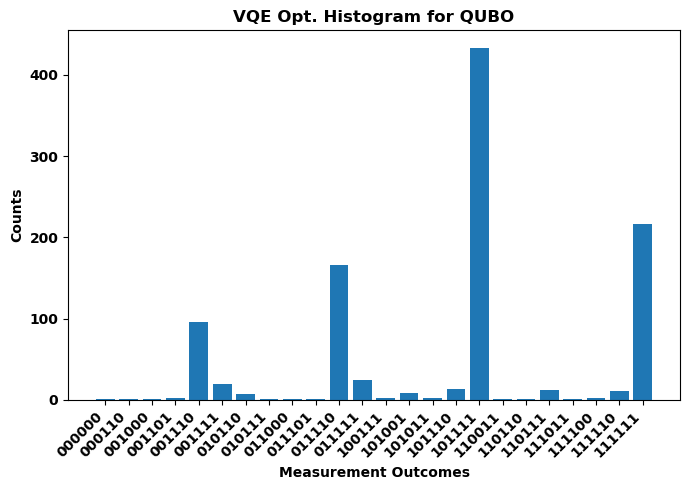

In [110]:
counts, bound_circuit = evaluate_and_plot_ansatz(expanded_ansatz, optimized_params, shots=1024, title="VQE Opt. Histogram for QUBO", figsize=(7, 5) )#, filename='hist_vqe_opt_co_ct1.svg')
#bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

In [111]:
import numpy as np

def get_top_k_counts_little_endian(counts: dict, k: int = 3) -> list[str]:
    """
    (Original function, kept for reference/use)
    Extracts the string keys corresponding to the top k highest counts,
    and then reverses each string to match the little-endian (Qiskit)
    convention where the string's first character is qubit 0.
    """
    # 1. Sort the dictionary items based on the value (count) in descending order.
    sorted_items = sorted(counts.items(), key=lambda item: item[1], reverse=True)

    # 2. Extract the first k keys (outcome strings).
    top_k_strings_big_endian = [item[0] for item in sorted_items[:k]]

    # 3. Reverse each string to convert from big-endian (e.g., Q_n-1...Q_0)
    #    to little-endian (Q_0...Q_n-1).
    top_k_strings_little_endian = [s[::-1] for s in top_k_strings_big_endian]

    return top_k_strings_little_endian

# --- NEW FUNCTION FOR BOOLEAN VECTORS ---

def get_top_k_boolean_vectors(counts: dict, k: int = 3) -> list[list[bool]]:
    """
    Extracts the top k outcome strings (in little-endian order) and converts
    them into a list of Boolean vectors, where '1' maps to True and '0' to False.

    Args:
        counts (dict): The dictionary of measurement outcomes and their counts.
        k (int): The number of top solutions to return.

    Returns:
        list[list[bool]]: A list of the top k solutions as Boolean vectors.
    """
    # Get the top k strings using the existing logic
    top_k_strings = get_top_k_counts_little_endian(counts, k)

    boolean_vectors = []
    for s in top_k_strings:
        # Convert the string of '0's and '1's into a list of Booleans.
        # '1' -> True, '0' -> False
        # The result preserves the little-endian order (Q0, Q1, Q2, ...)
        bool_vector = [char == '1' for char in s]
        boolean_vectors.append(bool_vector)

    return boolean_vectors

top_3_boolean_vectors = get_top_k_boolean_vectors(counts, k=3)

print(f"Input Counts (Big-Endian Keys): {counts}")
print("-" * 50)
print("Top 3 Solutions as Boolean Vectors (Little-Endian: Q0, Q1, Q2, ...):")

# Verification of the conversion for the top 3:
# 1. '000' (Big-Endian) -> '000' (Little-Endian) -> [False, False, False]
# 2. '010' (Big-Endian) -> '010' (Little-Endian) -> [False, True, False]
# 3. '111' (Big-Endian) -> '111' (Little-Endian) -> [True, True, True]

for i, vector in enumerate(top_3_boolean_vectors):
    print(f"Solution {i+1}: {vector}")

Input Counts (Big-Endian Keys): {'011110': 166, '111111': 216, '101111': 433, '101110': 13, '000000': 1, '001110': 96, '011111': 24, '111110': 11, '010110': 7, '001111': 20, '110111': 12, '111100': 2, '110110': 1, '101011': 3, '001101': 2, '000110': 1, '101001': 8, '001000': 1, '100111': 2, '011101': 1, '011000': 1, '010111': 1, '111011': 1, '110011': 1}
--------------------------------------------------
Top 3 Solutions as Boolean Vectors (Little-Endian: Q0, Q1, Q2, ...):
Solution 1: [True, True, True, True, False, True]
Solution 2: [True, True, True, True, True, True]
Solution 3: [False, True, True, True, True, False]


In [ ]:
# # auxiliary functions to sample most likely bitstring
# def to_bitstring(integer, num_bits):
#     result = np.binary_repr(integer, width=num_bits)
#     return [int(digit) for digit in result]
 
 
# keys = list(final_distribution_int.keys())
# values = list(final_distribution_int.values())
# most_likely = keys[np.argmax(np.abs(values))]
# most_likely_bitstring = to_bitstring(most_likely, len(graph))
# most_likely_bitstring.reverse()
 
# print("Result bitstring:", most_likely_bitstring)

In [ ]:
import numpy as np
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals

num_qubits = kl_div_mat_qubo.shape[0]

# --- 1. Define the Quadratic Program (QUBO) ---
qp = QuadraticProgram(name="CnotOptimization")

# Add binary variables: one for each CNOT candidate (0 to 41)
for i in range(num_qubits):
    qp.binary_var(name=f'x{i}')

# kl_vec = np.diag(kl_div_mat_qubo).copy()
# np.fill_diagonal(kl_div_mat_qubo, 0.0)
qp.minimize(quadratic=kl_div_mat_qubo, linear=kl_vec)
#qp.minimize(quadratic=kl_div_mat_qubo, linear=kl_vec)

op, offset = qp.to_ising()
print("offset: {}".format(offset))
print(qp.prettyprint())

NameError: name 'kl_vec' is not defined

In [52]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2

algorithm_globals.random_seed = 10598
pass_manager = generate_preset_pass_manager(optimization_level=2, backend=AerSimulator())
qaoa_noisy = QAOA(
    sampler=SamplerV2(seed=123, default_shots=2000),
    optimizer=COBYLA(maxiter=300),
    initial_point=[1, 1],
    pass_manager=pass_manager,
    reps=1
)
meo_noisy = MinimumEigenOptimizer(qaoa_noisy)

In [53]:
qaoa_result = meo_noisy.solve(qp)
print(qaoa_result.prettyprint())

objective function value: -5.826093094121047
variable values: x0=1.0, x1=1.0, x2=1.0, x3=1.0, x4=1.0, x5=1.0
status: SUCCESS


In [61]:
def get_filtered_samples(
    samples: list[SolutionSample],
    threshold: float = 0,
    allowed_status: tuple[OptimizationResultStatus] = (OptimizationResultStatus.SUCCESS,),
):
    res = []
    for s in samples:
        if s.status in allowed_status and s.probability > threshold:
            res.append(s)

    return res
    
filtered_samples = get_filtered_samples(
    qaoa_result.samples, threshold=0.001, allowed_status=(OptimizationResultStatus.SUCCESS,)
)
for s in filtered_samples:
    print(s)


SolutionSample(x=array([1., 1., 1., 1., 1., 1.]), fval=-5.826093094121047, probability=0.1205, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1., 1., 1., 1., 0., 1.]), fval=-5.5229454980652495, probability=0.111, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([0., 1., 1., 1., 1., 1.]), fval=-5.497926468128137, probability=0.093, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1., 1., 1., 1., 1., 0.]), fval=-5.475139028114249, probability=0.0845, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([0., 1., 1., 1., 1., 0.]), fval=-5.312397827850736, probability=0.0795, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([0., 1., 1., 1., 0., 1.]), fval=-5.264076427707173, probability=0.074, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(x=array([1., 1., 1., 1., 0., 0.]), fval=-5.219996040132578, probability=0.0755, status=<OptimizationResultStatus.SUCCESS: 0>)
SolutionSample(

objective function value: -5.826093094121047
variable values: x0=1.0, x1=1.0, x2=1.0, x3=1.0, x4=1.0, x5=1.0
status: SUCCESS


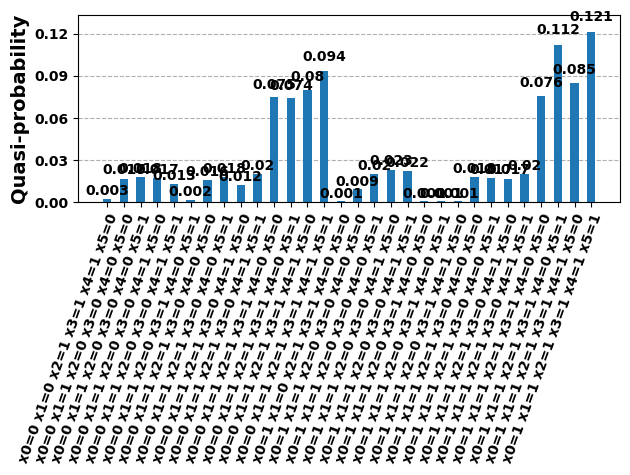

In [ ]:
from qiskit.visualization import plot_histogram

print(qaoa_result.prettyprint())

filtered_samples = get_filtered_samples(
    qaoa_result.samples, threshold=0.003, allowed_status=(OptimizationResultStatus.SUCCESS,)
)
samples_for_plot = {
    " ".join(f"{qaoa_result.variables[i].name}={int(v)}" for i, v in enumerate(s.x)): s.probability
    for s in filtered_samples
}
plot_histogram(samples_for_plot)

In [63]:
fvals = [s.fval for s in qaoa_result.samples]
probabilities = [s.probability for s in qaoa_result.samples]

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()

AttributeError: 'list' object has no attribute 'values'

In [67]:
from docplex.mp.model import Model
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.algorithms import GroverOptimizer, MinimumEigenOptimizer
from qiskit_optimization.minimum_eigensolvers import NumPyMinimumEigensolver

grover_optimizer = GroverOptimizer(6, num_iterations=10, sampler=StatevectorSampler(seed=123))
results = grover_optimizer.solve(qp)
print(results.prettyprint())

objective function value: -5.497926468128137
variable values: x0=0.0, x1=1.0, x2=1.0, x3=1.0, x4=1.0, x5=1.0
status: SUCCESS


In [ ]:
import numpy as np
from scipy.optimize import root_scalar, minimize
import time
from dwave.samplers import SteepestDescentSolver
from dwave.system import LeapHybridSampler  # Import for the Leap Hybrid Sampler
import dimod  # Import for working with QUBOs

# Convert QUBO matrix to dictionary format
def qubo_matrix_to_dict(Q):
    qubo = {}
    for i in range(Q.shape[0]):
        for j in range(Q.shape[1]):
            if Q[i, j] != 0:
                qubo[(i, j)] = Q[i, j]
    return qubo

def quantum_test_refactored(Q_matrix, initial_cnot_config, mode='sa'):
    """
    Perform a quantum or simulated annealing test on a pre-built QUBO matrix.

    Parameters:
    - Q_matrix (numpy.ndarray): The QUBO matrix to solve.
    - initial_cnot_config (list): List of CNOT configurations corresponding to the Q_matrix.
    - mode (str): Solver mode ('sa' for simulated annealing, 'qa' for quantum annealing).

    Returns:
    - tuple: (selected_cnots_df, qa_sol)
        selected_cnots_df: DataFrame with selected CNOTs and their scores.
        qa_sol: Solution vector indicating selected CNOTs.
    """
    # Convert Q matrix to QUBO dictionary
    qubo = qubo_matrix_to_dict(Q_matrix)

    if mode == 'qa':
        # Quantum (Hybrid) Solver
        print("Quantum (Hybrid) Solver Results...")
        sampler = LeapHybridSampler()
        sampleset = sampler.sample_qubo(qubo)
        print("Hybrid Solver run time (seconds): ", sampleset.info.get('run_time') / 1_000_000)
    else:
        # Simulated Annealing Solver
        print("Simulated Annealing Solver Results...")
        sampler = dimod.SimulatedAnnealingSampler() # Using a more standard SA sampler
        sampleset = sampler.sample_qubo(qubo, num_reads=1000)

    # Retrieve and analyze results
    print("Energy: ", sampleset.first.energy)
    print("Occurrences: ", sampleset.first.num_occurrences)

    # Store selected CNOTs from the solution
    sample_dict = sampleset.first.sample
    values = list(sample_dict.values())
    qa_sol = np.array(values).astype(int)

    # Calculate the score for each CNOT
    cnot_scores = Q_matrix @ qa_sol

    # Create a DataFrame for analysis
    selected_cnots_df = pd.DataFrame(initial_cnot_config, columns=['control', 'target'])
    selected_cnots_df['selected'] = values
    selected_cnots_df['score'] = cnot_scores

    # Filter for selected CNOTs and sort
    selected_cnots_df = selected_cnots_df[(selected_cnots_df['selected'] > 0) & (selected_cnots_df['score'] < 0)]
    selected_cnots_df = selected_cnots_df.sort_values(by='score', ascending=True).reset_index(drop=True)

    return selected_cnots_df, qa_sol

# Solve using simulated annealing
print("--- Starting Simulated Annealing ---")
sa_selected_cnots, sa_solution_vector = quantum_test_refactored(
    kl_div_mat_qubo, 
    initial_cnot_config, 
    mode='sa'
)

print("\nSimulated Annealing Results:")
print(sa_selected_cnots)

In [ ]:
#sa_solution_vector
print(initial_cnot_config)
i=0
for icnotp in initial_cnot_config:
    if sa_solution_vector[i]:
        print(i, icnotp)
    i+=1
print(sa_selected_cnots)